## Rotina para testar o chatbot na interface

**Objetivo:** Testar a capacidade do chatbot de responder perguntas dos usuários utilizando como contexto as informações fornecidas pela CETESB.

**Especificações**
- Definir o prompt do sistema do assistente.
- Estruturar o contexto contendo informações da CETESB sobre qualidade do ar e recomendações à saúde.
- Integrar os resultados do modelo de previsão de PM2.5 ao contexto fornecido ao LLM.
- Testar diferentes estratégias de fornecimento de contexto (prompt engineering).
- Avaliar diferentes configurações do modelo de linguagem (temperatura, tamanho do contexto, entre outras).
- Testar perguntas relacionadas à qualidade do ar, previsão, poluentes e recomendações de saúde.
- Avaliar a qualidade, consistência e relevância das respostas geradas.

In [38]:
import pandas as pd
import numpy as np
from google import genai
from dotenv import load_dotenv
import os
import pytz

In [39]:
load_dotenv()

True

In [40]:
client = genai.Client()

### 1. Definições e classificações já estabelecidas pela CETESB

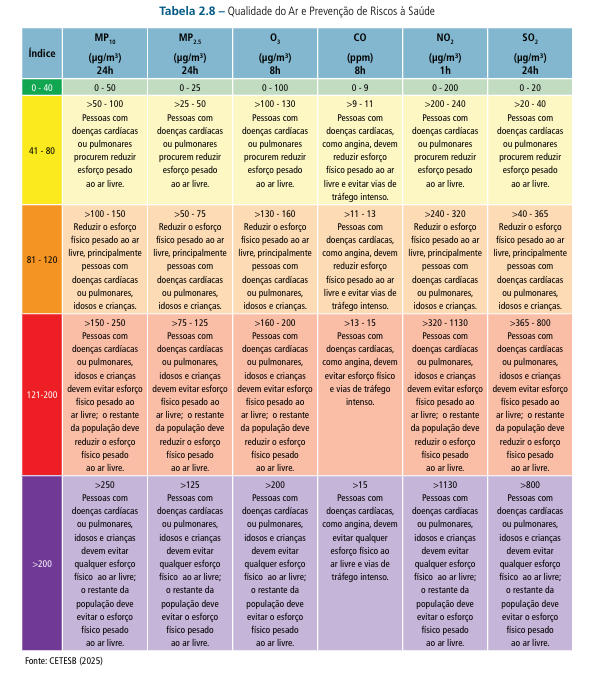

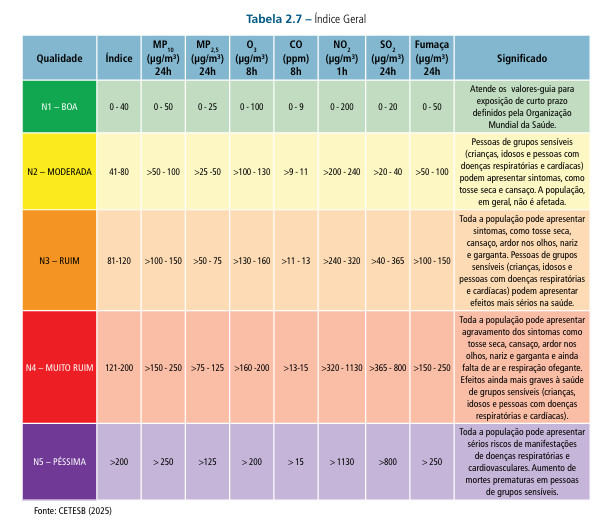

In [41]:
def consultar_classificacao_cetesb(pm25):
    """
    Classifica PM2.5 conforme faixas CETESB para média de 24h.
    Unidade: µg/m³
    """

    if pm25 <= 25:
        return "Boa"
    elif pm25 <= 50:
        return "Moderada"
    elif pm25 <= 75:
        return "Ruim"
    elif pm25 <= 125:
        return "Muito Ruim"
    else:
        return "Péssima"

In [42]:
def consultar_recomendacao_saude(classe):
    recomendacoes = {
        "Boa": (
            "A qualidade do ar está boa. Não há recomendações especiais para a população. "
            "Atividades ao ar livre podem ser realizadas normalmente."
        ),

        "Moderada": (
            "A qualidade do ar está moderada. Pessoas de grupos sensíveis, como crianças, idosos "
            "e pessoas com doenças cardíacas ou pulmonares, devem considerar reduzir esforço físico "
            "pesado ao ar livre, principalmente se apresentarem sintomas."
        ),

        "Ruim": (
            "A qualidade do ar está ruim. Crianças, idosos e pessoas com doenças cardíacas ou "
            "pulmonares devem reduzir esforço físico pesado ao ar livre. A população em geral deve "
            "evitar atividades muito intensas ou prolongadas."
        ),

        "Muito Ruim": (
            "A qualidade do ar está muito ruim. Crianças, idosos e pessoas com doenças cardíacas "
            "ou pulmonares devem evitar esforço físico pesado ao ar livre. A população em geral "
            "deve reduzir atividades físicas intensas e prolongadas."
        ),

        "Péssima": (
            "A qualidade do ar está péssima. Crianças, idosos e pessoas com doenças cardíacas "
            "ou pulmonares devem evitar qualquer esforço físico ao ar livre. A população em geral "
            "também deve evitar atividades físicas ao ar livre, especialmente esforço pesado."
        )
    }

    return recomendacoes.get(
        classe,
        "Classificação da qualidade do ar não reconhecida. Verifique a classe informada."
    )

In [43]:
contexto_poluente = """
PM2.5 são partículas muito finas presentes no ar, com diâmetro menor que 2,5 micrômetros.
Por serem pequenas, podem penetrar profundamente nos pulmões e afetar a saúde respiratória e cardiovascular.
"""


In [44]:
contexto_cetesb = """
As recomendações de saúde seguem a classificação de qualidade do ar da CETESB.
Grupos sensíveis incluem crianças, idosos e pessoas com doenças cardíacas ou pulmonares.
Quanto pior a qualidade do ar, maior deve ser a restrição a atividades físicas ao ar livre.
Para classes Moderada, Ruim, Muito Ruim e Péssima, o foco da recomendação é reduzir ou evitar esforço físico pesado ao ar livre, especialmente para grupos sensíveis.
"""

### 2. Abrindo previsão das próximas 24 horas

In [45]:
dados_previsao = pd.read_csv(
    "../data/forecast/forecast_LGBM_20260623.csv",
    index_col=0,
    parse_dates=True
)
dados_previsao.head()

,pm25_previsto
time,
2026-06-23 00:00:00+00:00,10.515089
2026-06-23 01:00:00+00:00,12.008247
2026-06-23 02:00:00+00:00,8.962146
2026-06-23 03:00:00+00:00,9.661303
2026-06-23 04:00:00+00:00,8.281111


In [46]:
# converter para horário local SP antes de exibir
sp_tz = pytz.timezone("America/Sao_Paulo")

def consultar_previsao(df):
    """
    Consulta a previsão das próximas 24 horas.

    """

    pm25 = df["pm25_previsto"]

    return {
        "inicio": pm25.index.min().astimezone(sp_tz),
        "fim": pm25.index.max().astimezone(sp_tz),
        "pm25_medio": pm25.mean(),
        "pm25_max": pm25.max(),
        "pm25_min": pm25.min(),
        "horario_pico": pm25.idxmax().astimezone(sp_tz),
        "horario_melhor": pm25.idxmin().astimezone(sp_tz)
    }

In [47]:
previsao = consultar_previsao(dados_previsao)

previsao

{'inicio': Timestamp('2026-06-22 21:00:00-0300', tz='America/Sao_Paulo'),
 'fim': Timestamp('2026-06-23 20:00:00-0300', tz='America/Sao_Paulo'),
 'pm25_medio': np.float64(12.007658617279235),
 'pm25_max': np.float64(24.483203108652635),
 'pm25_min': np.float64(7.564765745894157),
 'horario_pico': Timestamp('2026-06-23 10:00:00-0300', tz='America/Sao_Paulo'),
 'horario_melhor': Timestamp('2026-06-23 08:00:00-0300', tz='America/Sao_Paulo')}

### 3. Elaborar respostas

In [48]:
def responder_qualidade_ar(df):

    previsao = consultar_previsao(df)

    classe = consultar_classificacao_cetesb(
        previsao["pm25_medio"]
    )

    recomendacao = consultar_recomendacao_saude(classe)

    resposta = f"""
📅 Período analisado:
{previsao['inicio']:%d/%m/%Y %H:%M} até {previsao['fim']:%d/%m/%Y %H:%M}

🌫 PM2.5 médio previsto:
{previsao['pm25_medio']:.1f} µg/m³

📊 Classificação:
{classe}

📈 Maior concentração:
{previsao['pm25_max']:.1f} µg/m³ às {previsao['horario_pico']:%H:%M}

📉 Menor concentração:
{previsao['pm25_min']:.1f} µg/m³ às {previsao['horario_melhor']:%H:%M}

🏃 Recomendação:
{recomendacao}
"""

    return resposta

In [49]:
responder_qualidade_ar(dados_previsao)


'\n📅 Período analisado:\n22/06/2026 21:00 até 23/06/2026 20:00\n\n🌫 PM2.5 médio previsto:\n12.0 µg/m³\n\n📊 Classificação:\nBoa\n\n📈 Maior concentração:\n24.5 µg/m³ às 10:00\n\n📉 Menor concentração:\n7.6 µg/m³ às 08:00\n\n🏃 Recomendação:\nA qualidade do ar está boa. Não há recomendações especiais para a população. Atividades ao ar livre podem ser realizadas normalmente.\n'

In [50]:
def montar_contexto_llm(df):
    resposta_tecnica = responder_qualidade_ar(df)

    # tabela hora a hora
    df_local = df.copy()
    df_local.index = df_local.index.tz_convert("America/Sao_Paulo")

    tabela_horas = "\n".join([
        f"  {idx.strftime('%H:%M')} — {row['pm25_previsto']:.1f} µg/m³ "
        f"({consultar_classificacao_cetesb(row['pm25_previsto'])})"
        for idx, row in df_local.iterrows()
    ])

    contexto = f"""
Você é o assistente inteligente do projeto RESPIRA SP.

Use apenas as informações técnicas abaixo para responder ao usuário.

Informações técnicas:
{resposta_tecnica}

Previsão hora a hora (horário de São Paulo):
{tabela_horas}

Sobre o poluente monitorado:
{contexto_poluente}

Sobre as referências das recomendações:
{contexto_cetesb}

Regras:
- Responda em português do Brasil.
- Seja claro, natural e cuidadoso.
- Use os horários em horário de São Paulo (não UTC).
- Não invente valores.
- Não altere a classificação da qualidade do ar.
- Não dê diagnóstico médico.
- Se a pergunta for sobre sair, caminhar ou correr ao ar livre, use a recomendação de saúde.
- Quando a qualidade do ar estiver "Boa", ainda informe o melhor horário se o usuário pedir, usando o menor valor de PM2.5 previsto.
- Se o usuário perguntar sobre uma hora específica, use a tabela hora a hora.
- Use a tabela de hora a hora somente se uma pergunta vier específica sobre horários específicos. Evite jogar a tabela no chat.
"""
    return contexto

In [51]:
def responder_com_llm(pergunta, df):
    contexto = montar_contexto_llm(df)

    prompt = f"""
{contexto}

Pergunta do usuário:
{pergunta}

Resposta:
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash-lite",
        contents=prompt
    )

    return response.text

In [52]:
pergunta = "Hoje é um bom dia para sair ao ar livre? qual o melhor horário?"

resposta = responder_com_llm(
    pergunta=pergunta,
    df=dados_previsao
)

print(resposta)

Sim, hoje é um bom dia para sair ao ar livre! A qualidade do ar está boa e não há recomendações especiais. Você pode realizar atividades ao ar livre normalmente.

O melhor horário para aproveitar a qualidade do ar mais favorável é por volta das 08:00, quando a concentração de PM2.5 prevista é de 7.6 µg/m³.


In [53]:
pergunta = "Você tem a previsão para amanhã (27/06)?"

resposta = responder_com_llm(
    pergunta=pergunta,
    df=dados_previsao
)

print(resposta)

No momento, tenho a previsão da qualidade do ar para o período de 22/06/2026 às 21:00 até 23/06/2026 às 20:00. Não possuo informações para 27/06.


In [54]:
pergunta = "Como está a qualidade do ar hoje às 20h, seria uma boa hora para caminhar ao ar livre?"

resposta = responder_com_llm(
    pergunta=pergunta,
    df=dados_previsao
)

print(resposta)

Olá! Sobre a qualidade do ar hoje às 20h em São Paulo, a previsão é de **9.2 µg/m³**, o que classifica como **Boa**.

Como a qualidade do ar está boa, não há recomendações especiais. Atividades ao ar livre, como caminhar, podem ser realizadas normalmente.
